In [ ]:
import os
import torch
import random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import albumentations as A

if torch.cuda.is_available():
    device = 0
    gpu_name = torch.cuda.get_device_name(0)
    print(f"SUCCESS: High-Performance GPU Detected: {gpu_name}")
    print("Training will be fast.")
else:
    device = 'cpu'
    print("WARNING: No GPU detected. We are using the CPU.")
    print("Training will be extremely slow (hours or days).")

SUCCESS: High-Performance GPU Detected: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Training will be fast.


In [2]:
dataset_root = "/home/akash/Project Exhibition/YOLOv10/aircraft-skin-defects.v4-classification-isolated-5-classes-grayscale-prep.yolov8"

yaml_content = f"""
path: {dataset_root}
train: train/images
val: valid/images
test: test/images

nc: 5

names:
  0: crack
  1: dent
  2: missing-head
  3: paint-off
  4: scratch
"""

with open("aircraft_defects.yaml", "w") as f:
    f.write(yaml_content)

print("Map created: 'aircraft_defects.yaml'")
print(f"Pointing to dataset at: {dataset_root}")

Map created: 'aircraft_defects.yaml'
Pointing to dataset at: /home/akash/Project Exhibition/YOLOv10/aircraft-skin-defects.v4-classification-isolated-5-classes-grayscale-prep.yolov8


In [3]:
transform_pipeline = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
    ],
    bbox_params=A.BboxParams(
        format='yolo',
        label_fields=['class_labels']
    )
)

print("Augmentation Pipeline Built.")

Augmentation Pipeline Built.


In [4]:
from ultralytics import YOLO

# Load a YOLOv10 model – choose the variant that fits your task (n, s, m, l, x)
# Download the pretrained weights if not already present (e.g., 'yolov10n.pt')
model = YOLO('yolov10n.pt')   # or 'yolov10s.pt', 'yolov10m.pt', etc.

# Optional: set device explicitly (e.g., 'cuda:0' or 'cpu')
device = 'cuda'   # adjust if needed

print("Starting YOLOv10 Fine-Tuning...")

results = model.train(
    # Point to the dataset YAML (same as for YOLOv8)
    data='aircraft_defects.yaml',
    
    # Prevent system freeze in WSL / limit CPU threads
    workers=2,
    
    # Training hyperparameters
    epochs=50,      # number of epochs
    imgsz=640,      # image size
    batch=4,        # batch size (adjust for your VRAM)
    
    # Device and logging
    device=device,
    name='yolov10_aircraft_finetune',
    exist_ok=True,
    verbose=True
)

print("\nTraining Complete! Weights saved to runs/detect/yolov10_aircraft_finetune/weights/")

Starting YOLOv10 Fine-Tuning...
New https://pypi.org/project/ultralytics/8.4.26 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.13.12 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=aircraft_defects.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937

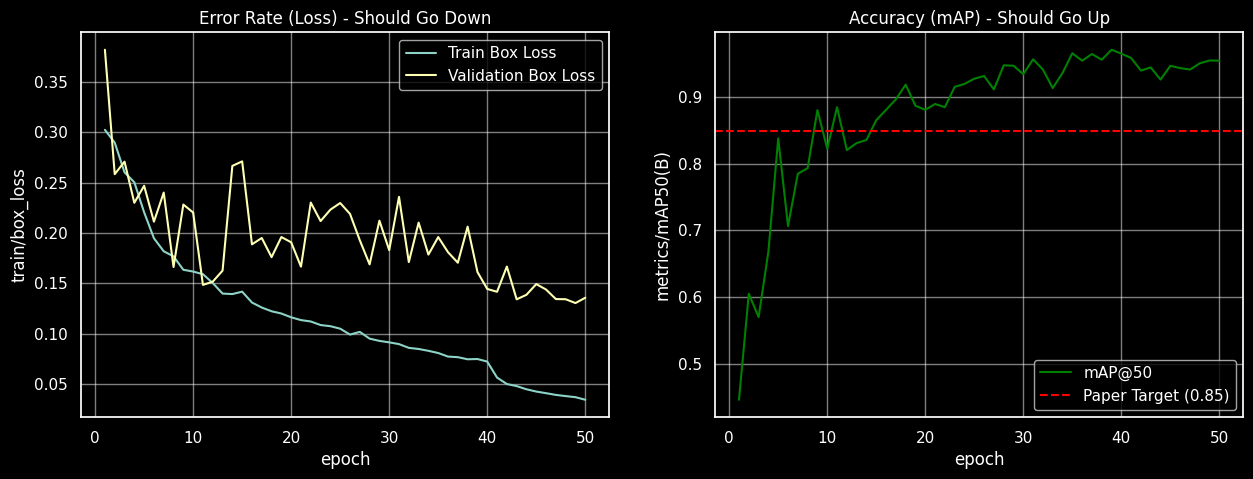

In [8]:
plt.style.use('dark_background')
plt.rcParams['grid.alpha'] = 0.5
%matplotlib inline

results_path = 'runs/detect/yolov10_aircraft_finetune/results.csv'

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    df.columns = df.columns.str.strip()

    fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    sns.lineplot(data=df, x='epoch', y='train/box_loss', label='Train Box Loss', ax=ax[0])
    sns.lineplot(data=df, x='epoch', y='val/box_loss', label='Validation Box Loss', ax=ax[0])

    ax[0].set_title("Error Rate (Loss) - Should Go Down")

    sns.lineplot(data=df, x='epoch', y='metrics/mAP50(B)', label='mAP@50', color='green', ax=ax[1])

    ax[1].set_title("Accuracy (mAP) - Should Go Up")
    ax[1].axhline(0.85, color='red', linestyle='--', label='Paper Target (0.85)')
    ax[1].legend()

    plt.show()
else:
    print("No results.csv found.")


0: 1280x1280 2 dents, 23.1ms
1: 1280x1280 1 missing-head, 23.1ms
2: 1280x1280 2 cracks, 23.1ms
Speed: 22.2ms preprocess, 23.1ms inference, 3.8ms postprocess per image at shape (1, 3, 1280, 1280)
Results saved to /home/akash/Project Exhibition/YOLOv10/runs/detect/predict


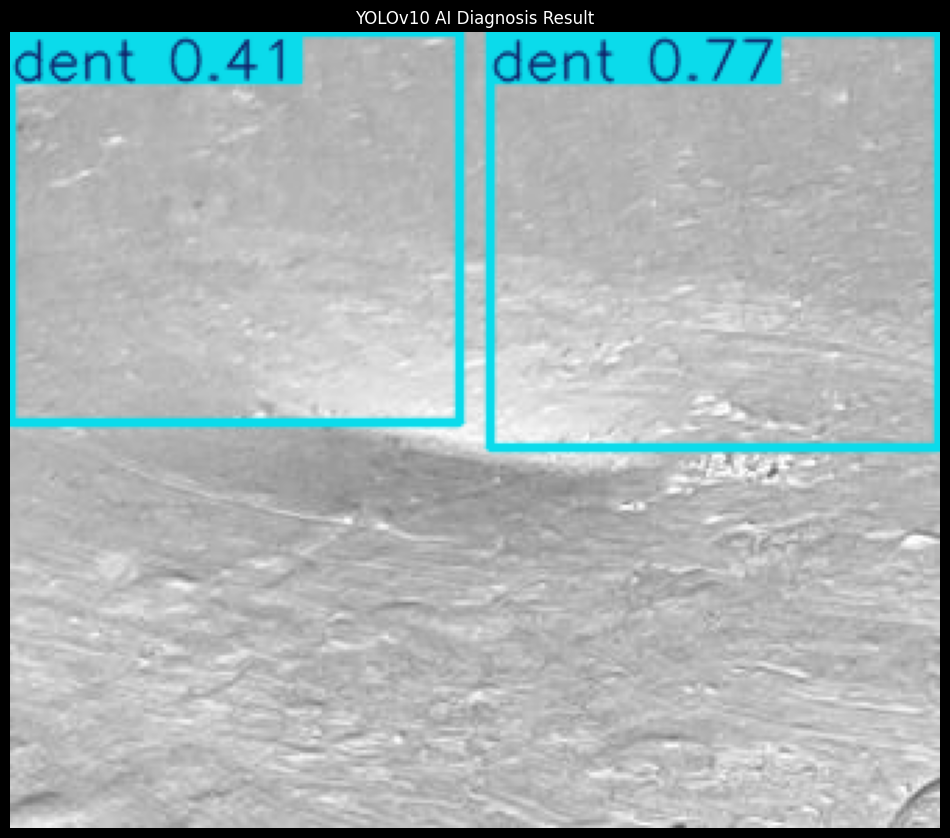

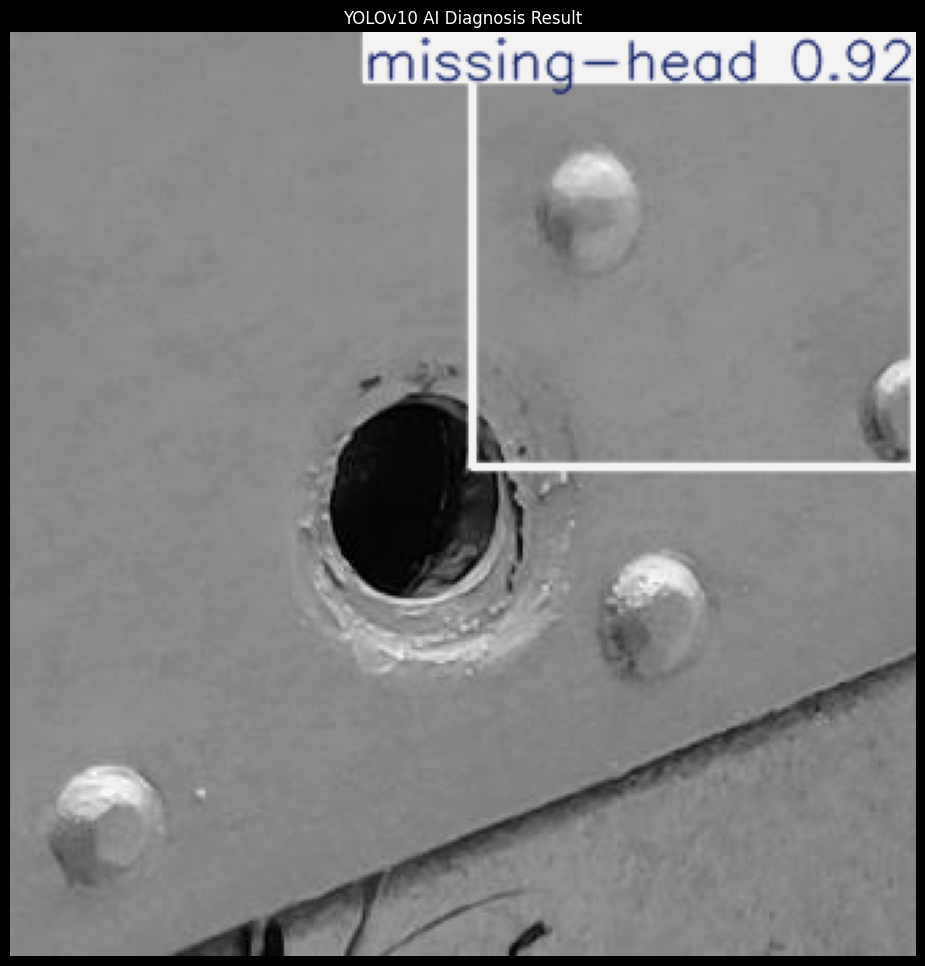

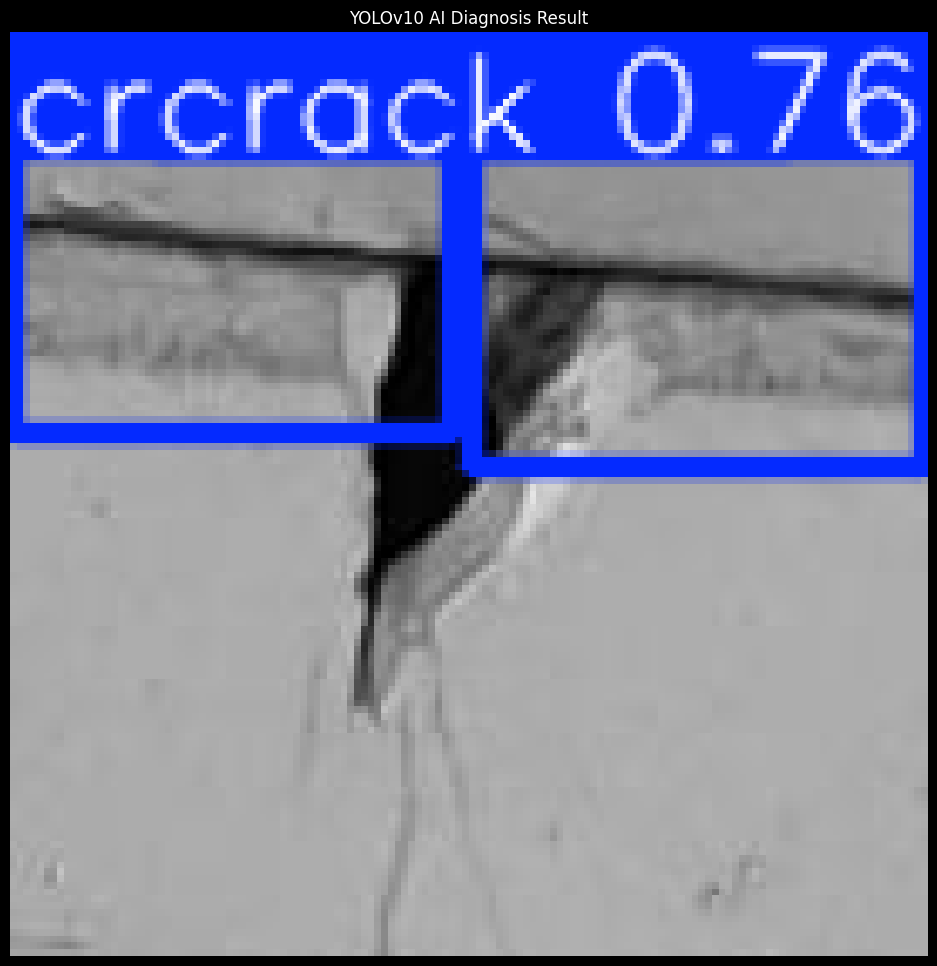

In [10]:
import glob
import cv2

# 1. Load the best model from your YOLOv10 training run
best_model_path = 'runs/detect/yolov10_aircraft_finetune/weights/best.pt'
model = YOLO(best_model_path)

# 2. Get a list of test images (adjust path if needed)
test_images = glob.glob("aircraft-skin-defects.v4-classification-isolated-5-classes-grayscale-prep.yolov8/test/images/*.jpg")  # Finds all .jpg files in the test folder

# 3. Pick 3 random images to show
if len(test_images) > 0:
    selected_images = random.sample(test_images, min(3, len(test_images)))
    
    # 4. Run the Prediction
    # conf=0.25: The AI must be at least 25% sure to draw a box.
    # save=True: Save the resulting image with drawn boxes.
    results = model.predict(selected_images, conf=0.25, imgsz=1280, save=True)
    
    # 5. Show the results
    for result in results:
        # Plot the result (draw the boxes on the image array)
        im_array = result.plot()
        
        plt.figure(figsize=(12, 12))
        plt.imshow(cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title("YOLOv10 AI Diagnosis Result")
        plt.show()
else:
    print("No images found in test/images. Check the folder path.")

Evaluating the model on the validation set...
Ultralytics 8.4.14 🚀 Python-3.13.12 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
YOLOv10n summary (fused): 102 layers, 2,266,143 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 72.3±109.6 MB/s, size: 33.1 KB)
val: Scanning /home/akash/Project Exhibition/YOLOv10/aircraft-skin-defects.v4-classification-isolated-5-classes-grayscale-prep.yolov8/valid/labels.cache... 148 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 148/148 36.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 4.4it/s 2.3s.3s
                   all        148        148      0.908      0.935      0.971      0.969
                 crack         43         43      0.871      0.977      0.965      0.965
                  dent         46         46      0.957      0.972      0.986      0.984
          missing-head         27         27

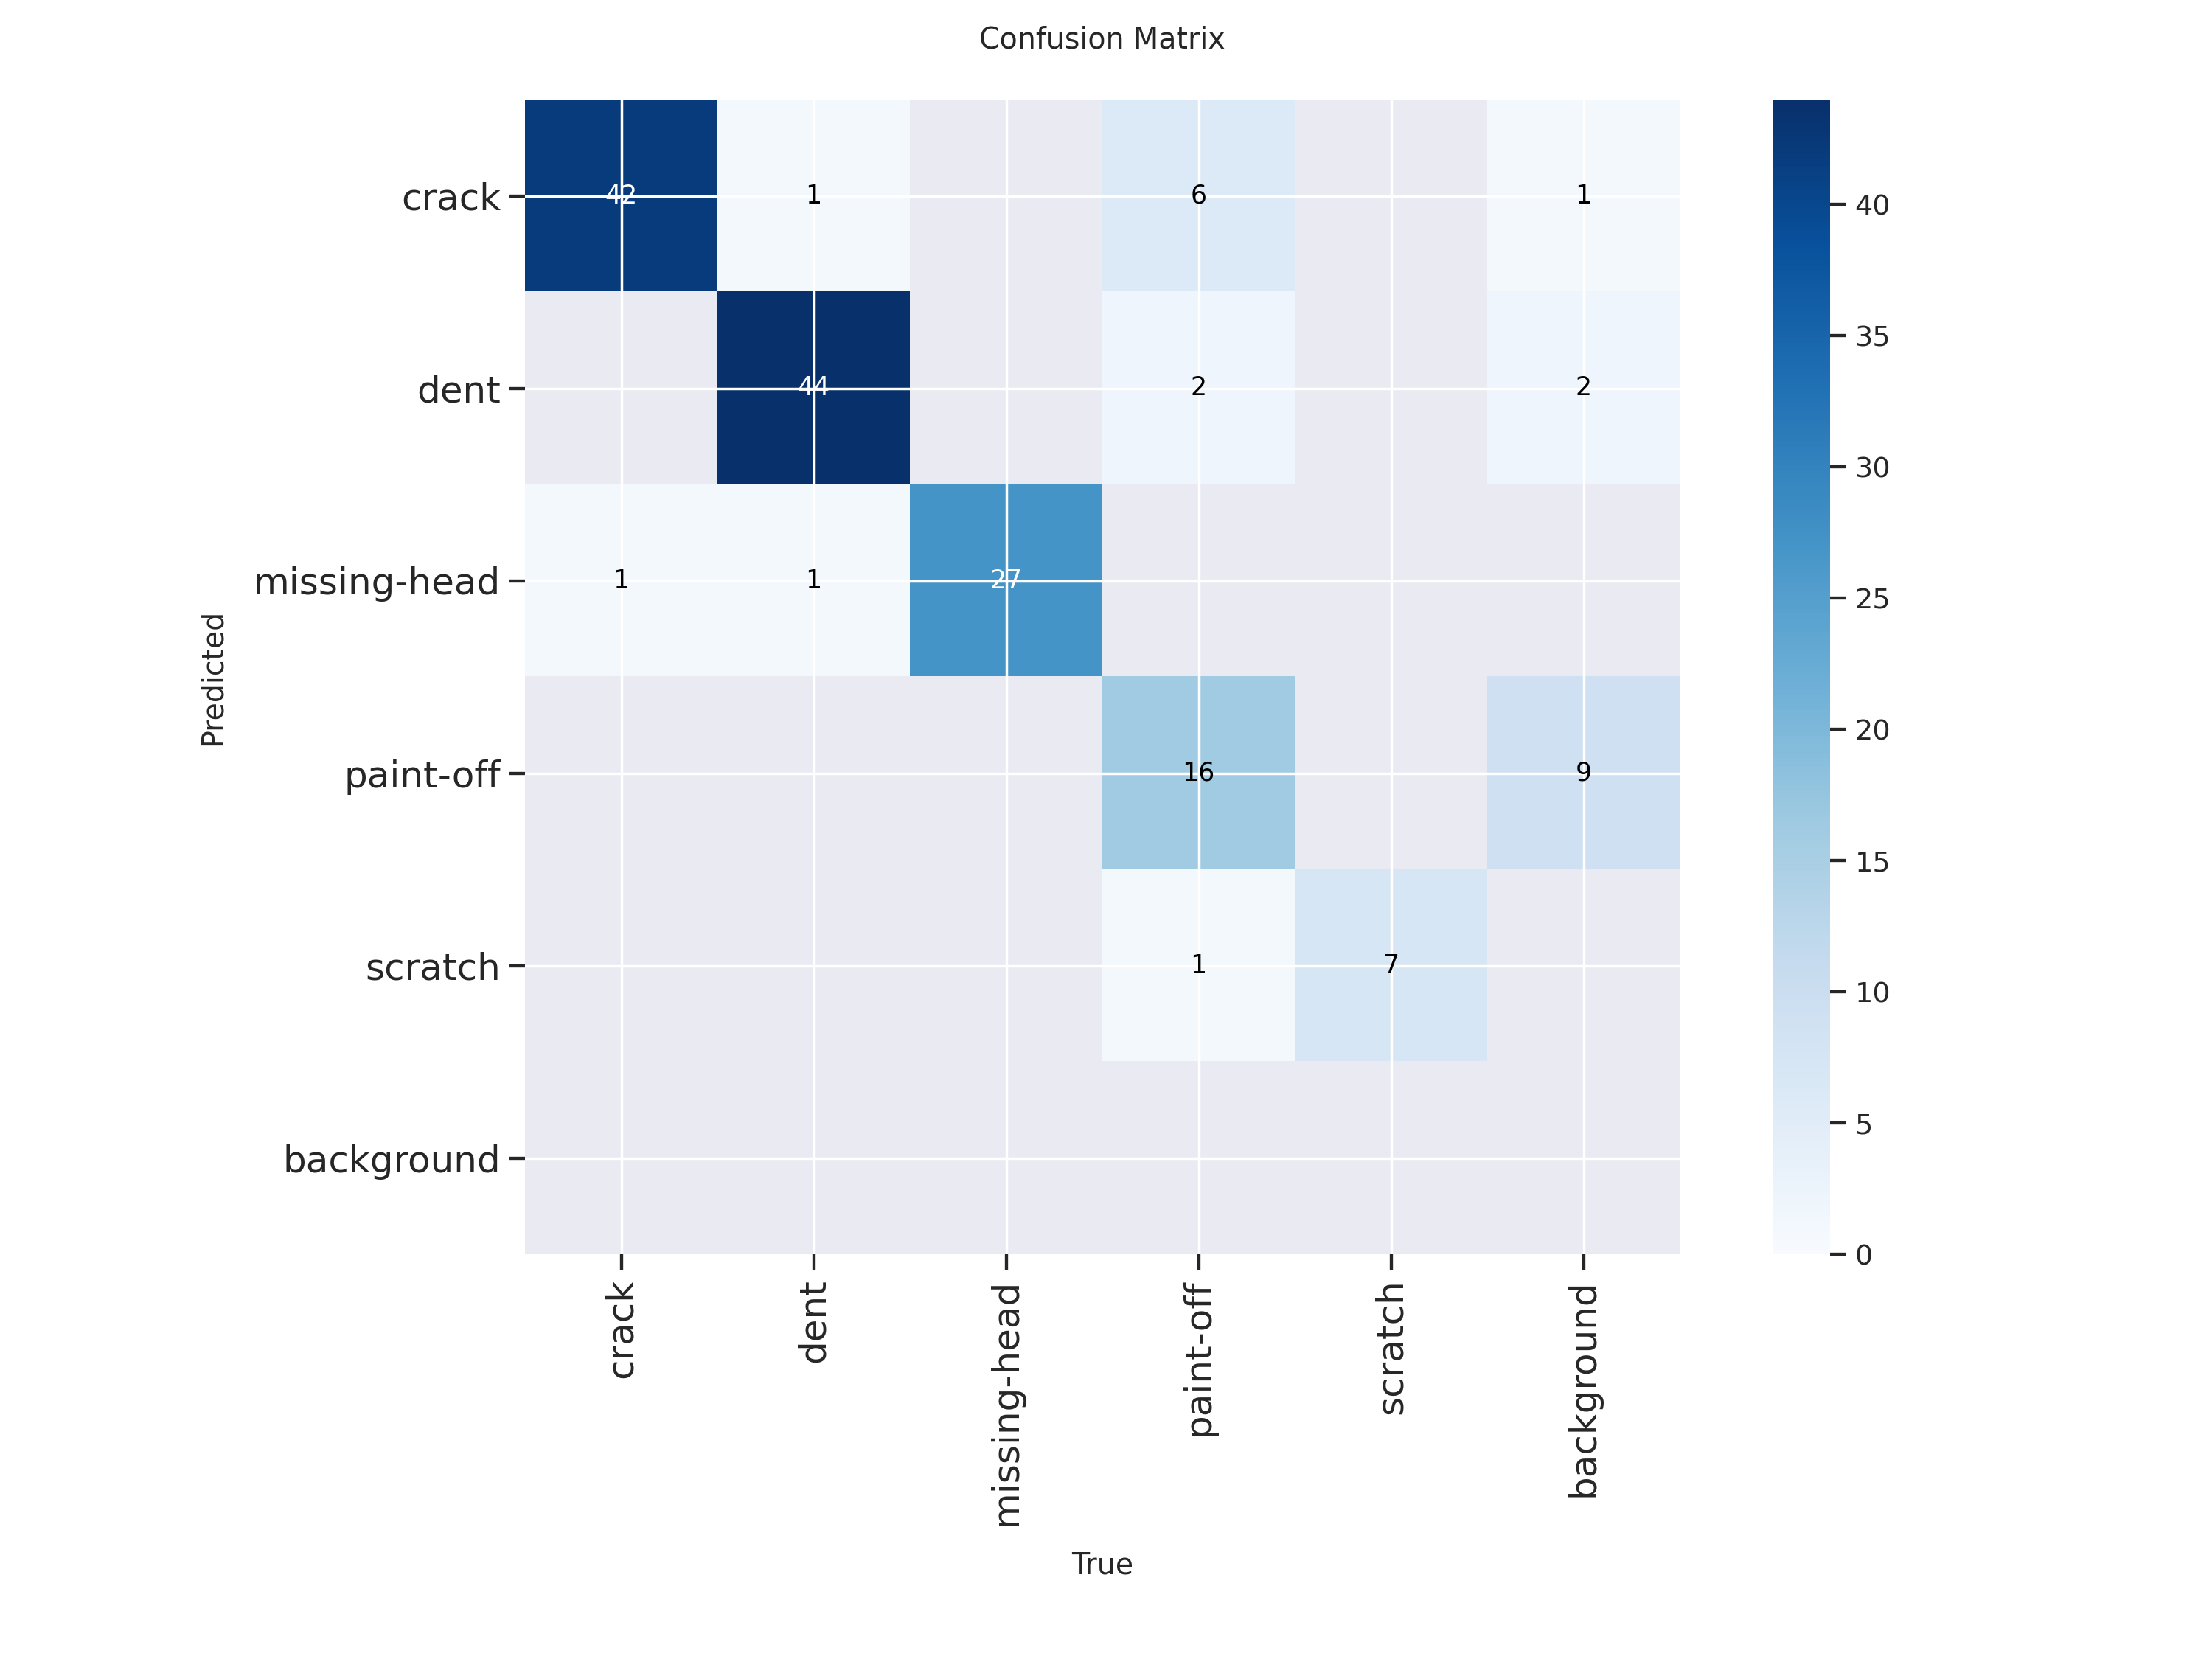

In [1]:
from IPython.display import Image, display
import os
import seaborn as sns
from ultralytics import YOLO

sns.set_theme()

# 1. Run validation to calculate evaluation metrics
print("Evaluating the model on the validation set...")

# Load YOUR trained YOLOv10 model
model = YOLO('runs/detect/yolov10_aircraft_finetune/weights/best.pt')

# Validate using your dataset configuration
metrics = model.val(data='aircraft-skin-defects.v4-classification-isolated-5-classes-grayscale-prep.yolov8/data.yaml')

# Extract Precision and Recall
precision = metrics.box.mp
recall = metrics.box.mr

# Calculate F1 Score (Harmonic mean of Precision and Recall)
if (precision + recall) > 0:
    f1_score = 2 * (precision * recall) / (precision + recall)
else:
    f1_score = 0.0

# 2. Print numeric evaluation metrics
print("\n--- Numeric Evaluation Metrics ---")
print(f"Mean Precision: {precision:.4f}")
print(f"Mean Recall:    {recall:.4f}")
print(f"F1-Score:       {f1_score:.4f}")
print(f"mAP50:          {metrics.box.map50:.4f}  <-- (Use this as your general 'Accuracy' metric)")
print(f"mAP50-95:       {metrics.box.map:.4f}")

print("\n*Note on Accuracy*: In Object Detection, standard 'Accuracy' (True Positives / Total) is generally replaced by mAP and F1-Score because the model must predict both the class AND the bounding box location. mAP50 is the industry standard proxy for object detection 'accuracy'.")

# 3. Locate and display the Evaluation Matrix (Confusion Matrix)
confusion_matrix_path = os.path.join(metrics.save_dir, 'confusion_matrix.png')

if os.path.exists(confusion_matrix_path):
    print("\n--- Evaluation Matrix (Confusion Matrix) ---")
    display(Image(filename=confusion_matrix_path, width=800))
else:
    print(f"\nConfusion matrix image not found at {confusion_matrix_path}")